In [1]:
# ==============================================================
# Step 1: Install Polars and mount Google Drive
# ==============================================================
!pip install -q polars pyarrow

import os
import gc
import polars as pl
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Input/output paths (handles both "MyDrive" and "My Drive" mount naming)
INPUT_PATH = "/content/drive/MyDrive/NIDS_Project/output/CICIDS2018_processed_final.parquet"
if not os.path.exists(INPUT_PATH):
    # Fallback for the space-separated "My Drive" mount path
    INPUT_PATH = "/content/drive/My Drive/NIDS_Project/output/CICIDS2018_processed_final.parquet"

OUTPUT_PATH = "/content/drive/MyDrive/NIDS_Project/output/CICIDS2018_sampled_cleaned.parquet"
if not os.path.exists(os.path.dirname(OUTPUT_PATH)):
    OUTPUT_PATH = "/content/drive/My Drive/NIDS_Project/output/CICIDS2018_sampled_cleaned.parquet"

print(f"[*] Input file path: {INPUT_PATH}")
print(f"[*] Output file path: {OUTPUT_PATH}")


Mounted at /content/drive
[*] Input file path: /content/drive/MyDrive/NIDS_Project/output/CICIDS2018_processed_final.parquet
[*] Output file path: /content/drive/MyDrive/NIDS_Project/output/CICIDS2018_sampled_cleaned.parquet


In [2]:
# ==============================================================
# Step 2: Initial lazy analysis of the label distribution (no RAM usage)
# ==============================================================
print("[*] Inspecting columns and the initial label distribution...")

# Lazy scan without loading the full dataset into memory
lazy_df = pl.scan_parquet(INPUT_PATH)

# Print column count
schema = lazy_df.schema
print(f"[+] Total Features: {len(schema.keys())}")

# Compute the class distribution
initial_counts = (
    lazy_df.group_by("Label")
    .agg(pl.len().alias("Count"))
    .sort("Count", descending=True)
    .collect()
)

print("\n--- Input label distribution ---")
print(initial_counts)


[*] Inspecting columns and the initial label distribution...


/tmp/ipykernel_3088/125717587.py:10: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema = lazy_df.schema


[+] Total Features: 39

--- Input label distribution ---
shape: (15, 2)
┌─────────────────────────────────┬──────────┐
│ Label                           ┆ Count    │
│ ---                             ┆ ---      │
│ cat                             ┆ u32      │
╞═════════════════════════════════╪══════════╡
│ Benign                          ┆ 45530463 │
│ DoS Hulk                        ┆ 1803160  │
│ DDoS-HOIC                       ┆ 1082291  │
│ DDoS-LOIC-HTTP                  ┆ 289302   │
│ Botnet Ares                     ┆ 142921   │
│ …                               ┆ …        │
│ Infiltration - Communication V… ┆ 203      │
│ Web Attack - Brute Force        ┆ 131      │
│ Web Attack - XSS                ┆ 113      │
│ Infiltration - Dropbox Downloa… ┆ 85       │
│ Web Attack - SQL                ┆ 39       │
└─────────────────────────────────┴──────────┘


In [3]:
# ==============================================================
# High-speed, memory-stable processing with DuckDB
# ==============================================================
import duckdb
import gc

print("[*] Processing the dataset with the DuckDB engine...")

# 1. Open a connection and set a random seed (standard DuckDB syntax)
con = duckdb.connect()
con.execute("SELECT setseed(0.42);")

# 2. Read column names and types to build an explicit downcasting SELECT
sample_df = con.execute(f"SELECT * FROM read_parquet('{INPUT_PATH}') LIMIT 1").df()

cast_columns = []
for col in sample_df.columns:
    col_type = str(sample_df[col].dtype).lower()
    if col == "Label":
        cast_columns.append(f'"{col}"')
    elif "float" in col_type:
        cast_columns.append(f'CAST("{col}" AS FLOAT) AS "{col}"')
    elif "int" in col_type:
        cast_columns.append(f'CAST("{col}" AS INTEGER) AS "{col}"')
    else:
        cast_columns.append(f'"{col}"')

select_clause = ",\n    ".join(cast_columns)

# 3. Stream directly from disk to disk without occupying Colab RAM
query = f"""
COPY (
    SELECT
        {select_clause}
    FROM read_parquet('{INPUT_PATH}')
    WHERE
        -- 1. Filter out noisy Web Attack and Infiltration classes
        Label NOT ILIKE '%Web Attack%'
        AND Label NOT ILIKE '%Infiltration%'

        -- 2. Targeted undersampling of overrepresented classes
        AND (
            (Label = 'Benign' AND random() <= 0.30)        -- 70% reduction
            OR (Label = 'DoS Hulk' AND random() <= 0.30)   -- 70% reduction
            OR (Label = 'DDoS-HOIC' AND random() <= 0.50)  -- 50% reduction
            OR (Label NOT IN ('Benign', 'DoS Hulk', 'DDoS-HOIC')) -- keep all other attack classes
        )
) TO '{OUTPUT_PATH}' (FORMAT PARQUET, COMPRESSION SNAPPY);
"""

# Execute the query
con.execute(query)
con.close()
gc.collect()

print(f"[+] Processing complete. Cleaned, reduced-size file saved to:\n{OUTPUT_PATH}")


[*] Processing the dataset with the DuckDB engine...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

[+] Processing complete. Cleaned, reduced-size file saved to:
/content/drive/MyDrive/NIDS_Project/output/CICIDS2018_sampled_cleaned.parquet


In [4]:
# ==============================================================
# Step 4: Verify and inspect the final dataset statistics
# ==============================================================
final_scan = pl.scan_parquet(OUTPUT_PATH)

final_stats = (
    final_scan.group_by("Label")
    .agg(pl.len().alias("Final_Count"))
    .sort("Final_Count", descending=True)
    .collect()
)

total_rows = final_stats["Final_Count"].sum()

# Compute the percentage share of each class in the final dataset
final_stats = final_stats.with_columns(
    (pl.col("Final_Count") / total_rows * 100).round(2).alias("Percentage (%)")
)

print(f"\n=======================================================")
print(f"Total final records: {total_rows:,}")
print(f"=======================================================\n")
print(final_stats)



Total final records: 15,300,843

shape: (9, 3)
┌────────────────┬─────────────┬────────────────┐
│ Label          ┆ Final_Count ┆ Percentage (%) │
│ ---            ┆ ---         ┆ ---            │
│ str            ┆ u32         ┆ f64            │
╞════════════════╪═════════════╪════════════════╡
│ Benign         ┆ 13657893    ┆ 89.26          │
│ DoS Hulk       ┆ 541560      ┆ 3.54           │
│ DDoS-HOIC      ┆ 541394      ┆ 3.54           │
│ DDoS-LOIC-HTTP ┆ 289302      ┆ 1.89           │
│ Botnet Ares    ┆ 142921      ┆ 0.93           │
│ SSH-BruteForce ┆ 94197       ┆ 0.62           │
│ DoS GoldenEye  ┆ 22559       ┆ 0.15           │
│ DoS Slowloris  ┆ 8490        ┆ 0.06           │
│ DDoS-LOIC-UDP  ┆ 2527        ┆ 0.02           │
└────────────────┴─────────────┴────────────────┘


In [5]:
# ==============================================================
# Step 5: Handle Inf/NaN values and split the data (stratified train/val/test)
# ==============================================================
import polars as pl
import numpy as np
import json
import gc

print("[*] Reading the cleaned dataset to build the data splits...")

# Read the filtered dataset
df = pl.read_parquet(OUTPUT_PATH)

# 1. Replace Inf/-Inf with null, then fill nulls with 0
feature_cols = [c for c in df.columns if c != "Label"]

df = df.with_columns([
    pl.when(pl.col(c).is_infinite())
      .then(None)
      .otherwise(pl.col(c))
      .alias(c)
    for c in feature_cols
])

# Fill nulls originating from Inf values with 0 (standard for network flow features)
df = df.fill_null(0)

# 2. Build the label encoding map
unique_labels = sorted(df["Label"].unique().to_list())
# Ensure Benign is always class 0
if "Benign" in unique_labels:
    unique_labels.remove("Benign")
    unique_labels = ["Benign"] + unique_labels

label_to_id = {label: idx for idx, label in enumerate(unique_labels)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

print("\n[+] Label mapping:")
for k, v in label_to_id.items():
    print(f"    {v}: {k}")

# Apply the encoding to the Label column
df = df.with_columns(
    pl.col("Label").replace_strict(label_to_id).cast(pl.UInt8).alias("target")
)

# 3. Stratified sampling for Train (70%) / Val (15%) / Test (15%)
print("\n[*] Running the stratified split...")

# Add a uniform random column for precise stratification
np.random.seed(42)
random_vals = np.random.rand(len(df)).astype(np.float32)
df = df.with_columns(pl.Series("rand_split", random_vals))

train_df = df.filter(pl.col("rand_split") < 0.70).drop("rand_split")
val_df   = df.filter((pl.col("rand_split") >= 0.70) & (pl.col("rand_split") < 0.85)).drop("rand_split")
test_df  = df.filter(pl.col("rand_split") >= 0.85).drop("rand_split")

# Free the source DataFrame
del df
gc.collect()

print(f"[+] Train records:      {len(train_df):,}")
print(f"[+] Validation records: {len(val_df):,}")
print(f"[+] Test records:       {len(test_df):,}")


[*] Reading the cleaned dataset to build the data splits...

[+] Label mapping:
    0: Benign
    1: Botnet Ares
    2: DDoS-HOIC
    3: DDoS-LOIC-HTTP
    4: DDoS-LOIC-UDP
    5: DoS GoldenEye
    6: DoS Hulk
    7: DoS Slowloris
    8: SSH-BruteForce

[*] Running the stratified split...
[+] Train records:      10,711,603
[+] Validation records: 2,294,557
[+] Test records:       2,294,683


In [6]:
# ==============================================================
# Dimensionality-reduction visualization with Benign-weighted sampling,
# saved to Google Drive
# ==============================================================
import os
import gc
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# 1. Set the output directory for the generated images
SAVE_DIR = os.path.dirname(OUTPUT_PATH)
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"[*] Image output directory: {SAVE_DIR}")

# 2. Asymmetric sampling (10,000 Benign samples, 1,000 samples per attack class)
print("\n[*] Sampling with a much larger weight for Benign traffic...")

sampled_dfs = []
for class_id in range(9):
    class_subset = train_df.filter(pl.col("target") == class_id)
    n_available = len(class_subset)

    # Determine the sample quota
    if class_id == 0:
        target_sample_size = 10000  # larger sample for benign traffic
    else:
        target_sample_size = 1000   # sample size for each attack class

    n_sample = min(n_available, target_sample_size)
    sampled_dfs.append(
        class_subset.sample(n=n_sample, seed=42, shuffle=True)
    )

viz_df = pl.concat(sampled_dfs)
print(f"[+] Total selected records: {len(viz_df):,}")
print(f"    - Benign share: {len(viz_df.filter(pl.col('target') == 0)):,} records")
print(f"    - Total attack share: {len(viz_df.filter(pl.col('target') != 0)):,} records")

# 3. Extract and standardize the features
feature_columns = [col for col in viz_df.columns if col not in ["Label", "target"]]
X_sample = viz_df.select(feature_columns).to_numpy()
y_sample = viz_df["target"].to_numpy()

print("\n[*] Standardizing features (StandardScaler)...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

# 4. Run PCA
print("[*] Running PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_ratio = pca.explained_variance_ratio_

# 5. Run t-SNE
print("[*] Running t-SNE (this may take about a minute)...")
tsne = TSNE(
    n_components=2,
    perplexity=40,
    n_iter=1000,
    init="pca",
    learning_rate="auto",
    random_state=42,
    n_jobs=-1
)
X_tsne = tsne.fit_transform(X_scaled)

# 6. Run UMAP
print("[*] Running UMAP...")
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.15,
    metric="euclidean",
    random_state=42,
    n_jobs=-1
)
X_umap = umap_reducer.fit_transform(X_scaled)


[*] Image output directory: /content/drive/MyDrive/NIDS_Project/output

[*] Sampling with a much larger weight for Benign traffic...
[+] Total selected records: 18,000
    - Benign share: 10,000 records
    - Total attack share: 8,000 records

[*] Standardizing features (StandardScaler)...
[*] Running PCA...
[*] Running t-SNE (this may take about a minute)...


/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[*] Running UMAP...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[+] Combined figure saved:
    -> /content/drive/MyDrive/NIDS_Project/output/NIDS_Dimensionality_Reduction.png


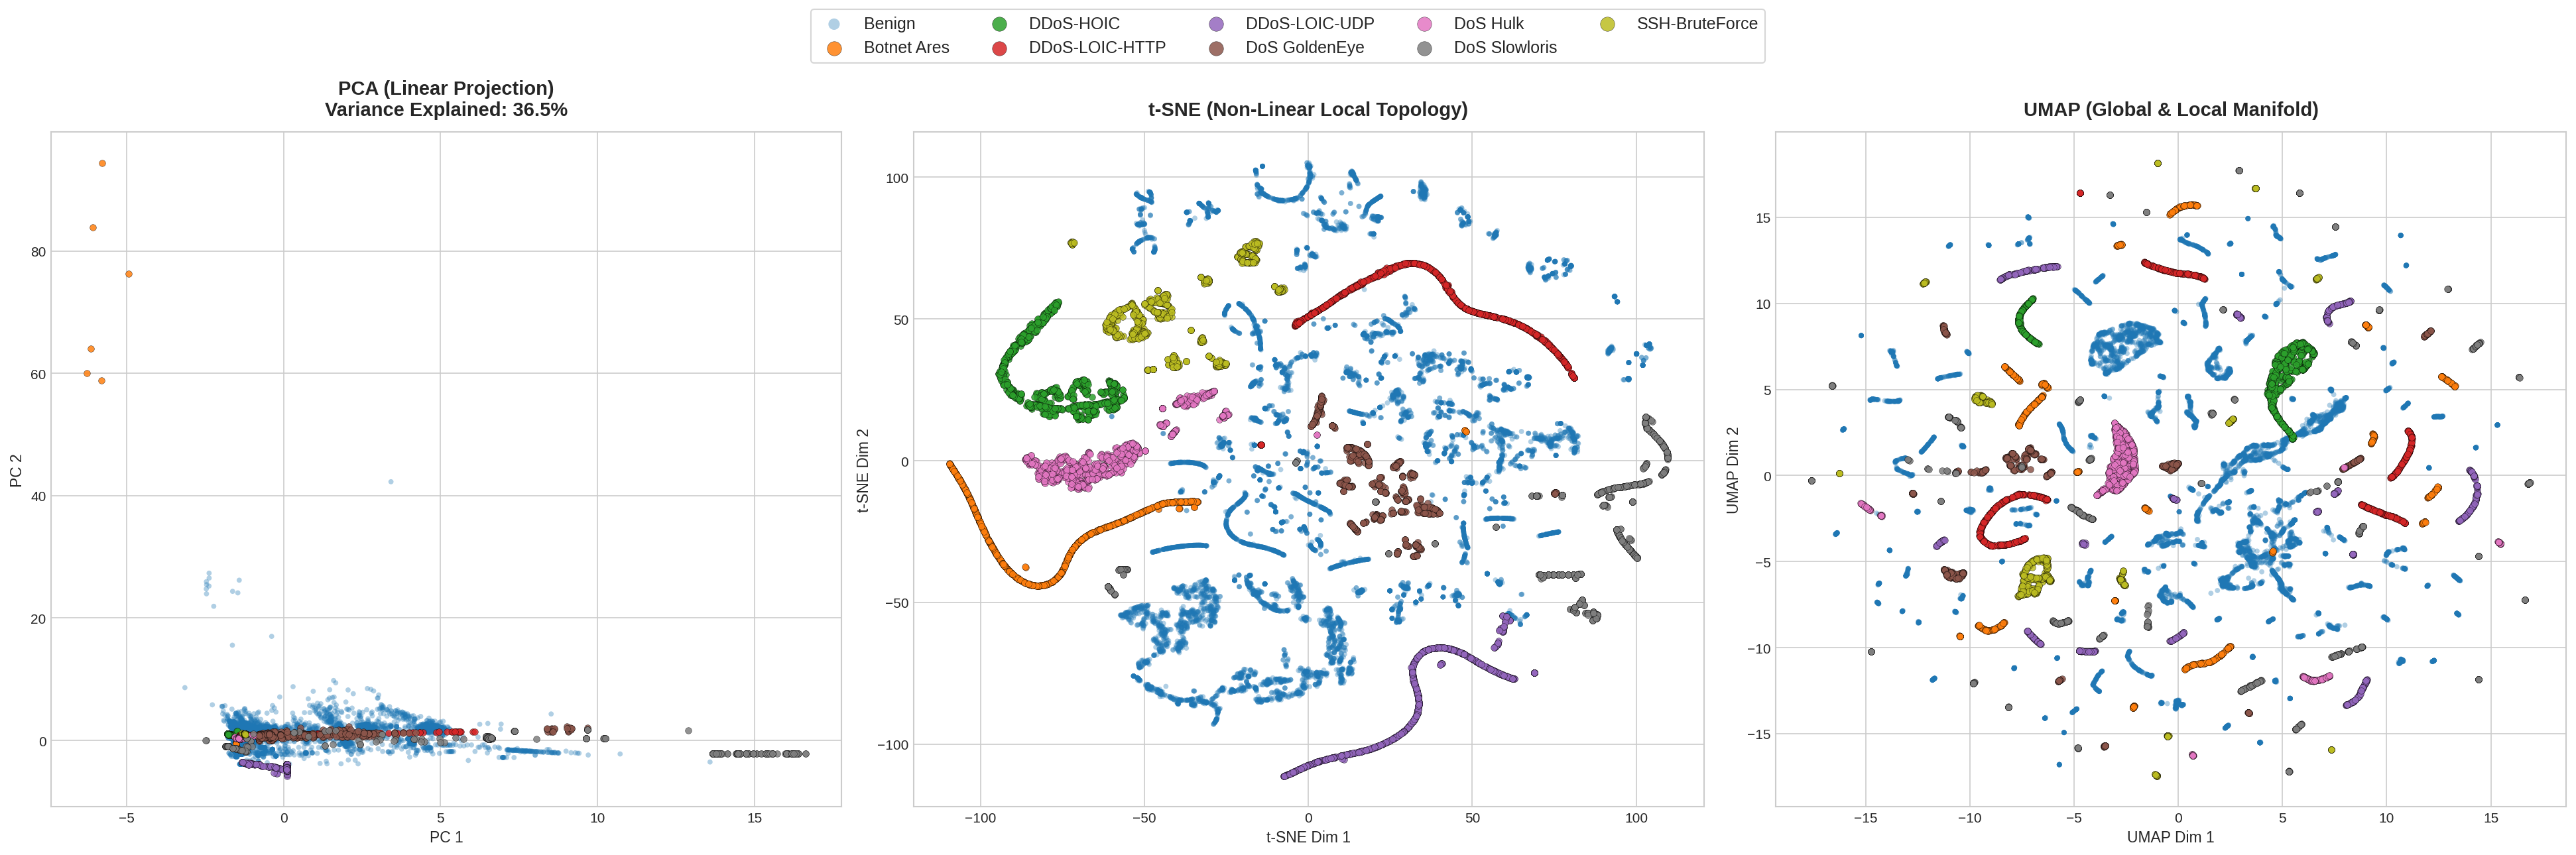

[+] Individual figure saved: /content/drive/MyDrive/NIDS_Project/output/NIDS_PCA_Single.png
[+] Individual figure saved: /content/drive/MyDrive/NIDS_Project/output/NIDS_t-SNE_Single.png
[+] Individual figure saved: /content/drive/MyDrive/NIDS_Project/output/NIDS_UMAP_Single.png


60

In [7]:
# ==============================================================
# Plot and save the dimensionality-reduction figures (combined + individual)
# ==============================================================
plt.style.use("seaborn-v0_8-whitegrid")
palette = sns.color_palette("tab10", n_colors=9)
label_names = [id_to_label[i] for i in range(9)]

# 1. Plot and save the combined 3-panel comparison figure
fig, axes = plt.subplots(1, 3, figsize=(26, 8), dpi=150)

plots_config = [
    (X_pca, f"PCA (Linear Projection)\nVariance Explained: {(var_ratio.sum()):.1%}", "PC 1", "PC 2"),
    (X_tsne, "t-SNE (Non-Linear Local Topology)", "t-SNE Dim 1", "t-SNE Dim 2"),
    (X_umap, "UMAP (Global & Local Manifold)", "UMAP Dim 1", "UMAP Dim 2")
]

for idx, (data, title, xlabel, ylabel) in enumerate(plots_config):
    ax = axes[idx]

    # Draw Benign traffic first, in the background layer, with higher transparency
    mask_benign = (y_sample == 0)
    ax.scatter(
        data[mask_benign, 0], data[mask_benign, 1],
        c=[palette[0]], label=label_names[0],
        alpha=0.35, s=14, edgecolors="none", zorder=1
    )

    # Draw attack classes on top (zorder=2) so they stand out clearly
    for class_id in range(1, 9):
        mask_attack = (y_sample == class_id)
        ax.scatter(
            data[mask_attack, 0], data[mask_attack, 1],
            c=[palette[class_id]], label=label_names[class_id],
            alpha=0.85, s=22, edgecolors="black", linewidths=0.2, zorder=2
        )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=5, fontsize=12,
    frameon=True, markerscale=2.2
)

plt.tight_layout()

# Save the combined comparison figure to Drive
combined_img_path = os.path.join(SAVE_DIR, "NIDS_Dimensionality_Reduction.png")
fig.savefig(combined_img_path, dpi=300, bbox_inches="tight")
print(f"[+] Combined figure saved:\n    -> {combined_img_path}")

plt.show()
plt.close(fig)

# 2. Save each plot individually at the highest quality
for data, name, xlabel, ylabel in [
    (X_pca, "PCA", "Principal Component 1", "Principal Component 2"),
    (X_tsne, "t-SNE", "Dimension 1", "Dimension 2"),
    (X_umap, "UMAP", "Dimension 1", "Dimension 2")
]:
    fig_single, ax = plt.subplots(figsize=(10, 8), dpi=200)

    # Plot Benign traffic
    mask_b = (y_sample == 0)
    ax.scatter(data[mask_b, 0], data[mask_b, 1], c=[palette[0]], label=label_names[0], alpha=0.35, s=16, edgecolors="none")

    # Plot attack classes
    for c_id in range(1, 9):
        mask_a = (y_sample == c_id)
        ax.scatter(data[mask_a, 0], data[mask_a, 1], c=[palette[c_id]], label=label_names[c_id], alpha=0.85, s=24, edgecolors="black", linewidths=0.2)

    ax.set_title(f"NIDS Feature Space Projection: {name}", fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(loc="best", fontsize=9, markerscale=1.8, frameon=True)

    single_path = os.path.join(SAVE_DIR, f"NIDS_{name}_Single.png")
    fig_single.savefig(single_path, dpi=300, bbox_inches="tight")
    plt.close(fig_single)
    print(f"[+] Individual figure saved: {single_path}")

gc.collect()


In [8]:
# ==============================================================
# Step 9: Prepare the LightGBM datasets with optimized memory handling
# ==============================================================
import os
import gc
import json
import joblib
import numpy as np
import polars as pl
import lightgbm as lgb
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print("[*] Preparing the Train, Val, and Test arrays...")

# 1. Extract the feature columns
feature_names = [col for col in train_df.columns if col not in ["Label", "target"]]
print(f"[+] Number of network features: {len(feature_names)}")

# 2. Convert Train to NumPy and compute class weights
X_train = train_df.select(feature_names).to_numpy().astype(np.float32)
y_train = train_df["target"].to_numpy().astype(np.uint8)

# Compute inverse-frequency weights to offset the 9-class imbalance
classes = np.unique(y_train)
class_weights_arr = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
# Map class weights onto every training sample via fast vectorized indexing
sample_weights = class_weights_arr[y_train].astype(np.float32)

print("[*] Building the lgb.Dataset structure for the training data...")
train_data = lgb.Dataset(
    X_train,
    label=y_train,
    weight=sample_weights,
    feature_name=feature_names,
    free_raw_data=True  # automatically discard the raw matrix after histogram binning
)

# Free temporary memory
del train_df, X_train, y_train, sample_weights
gc.collect()

# 3. Convert Validation
X_val = val_df.select(feature_names).to_numpy().astype(np.float32)
y_val = val_df["target"].to_numpy().astype(np.uint8)

val_data = lgb.Dataset(
    X_val,
    label=y_val,
    reference=train_data,
    feature_name=feature_names,
    free_raw_data=True
)

del val_df, X_val, y_val
gc.collect()

# 4. Keep Test for the final evaluation
X_test = test_df.select(feature_names).to_numpy().astype(np.float32)
y_test = test_df["target"].to_numpy().astype(np.uint8)

del test_df
gc.collect()

print("[+] All datasets prepared with optimized memory usage.")


[*] Preparing the Train, Val, and Test arrays...
[+] Number of network features: 38
[*] Building the lgb.Dataset structure for the training data...
[+] All datasets prepared with optimized memory usage.


In [9]:
# ==============================================================
# Step 10: Define the multi-class hyperparameters and train with early stopping
# ==============================================================
params = {
    "objective": "multiclass",
    "num_class": 9,
    "boosting_type": "gbdt",
    "metric": ["multi_logloss", "multi_error"],
    "learning_rate": 0.08,
    "num_leaves": 63,           # suitable depth for capturing complex non-linear relationships
    "max_depth": 10,
    "min_child_samples": 50,    # guards against overfitting on very small attack classes
    "subsample": 0.8,           # row subsampling per iteration
    "subsample_freq": 1,
    "colsample_bytree": 0.8,    # feature subsampling
    "n_jobs": -1,               # use all available Colab CPU cores
    "random_state": 42,
    "verbose": -1
}

print("[*] Starting LightGBM training on 10.7 million records...")
print("    (typically takes 2 to 4 minutes thanks to the histogram-based algorithm)\n")

# Train with validation monitoring and early stopping
evals_result = {}
callbacks = [
    lgb.early_stopping(stopping_rounds=30, verbose=True),
    lgb.log_evaluation(period=20),
    lgb.record_evaluation(evals_result)
]

model = lgb.train(
    params,
    train_data,
    num_boost_round=350,
    valid_sets=[train_data, val_data],
    valid_names=["Train", "Validation"],
    callbacks=callbacks
)

# Free the training datasets from memory
del train_data, val_data
gc.collect()

print("\n[+] Training completed successfully.")


[*] Starting LightGBM training on 10.7 million records...
    (typically takes 2 to 4 minutes thanks to the histogram-based algorithm)

Training until validation scores don't improve for 30 rounds
[20]	Train's multi_logloss: 0.0786683	Train's multi_error: 4.09816e-06	Validation's multi_logloss: 0.0791247	Validation's multi_error: 2.78921e-05
[40]	Train's multi_logloss: 0.00454942	Train's multi_error: 6.39114e-07	Validation's multi_logloss: 0.00461467	Validation's multi_error: 6.53721e-06
[60]	Train's multi_logloss: 0.00026583	Train's multi_error: 8.13418e-08	Validation's multi_logloss: 0.000284122	Validation's multi_error: 3.92233e-06
[80]	Train's multi_logloss: 1.56816e-05	Train's multi_error: 2.32405e-08	Validation's multi_logloss: 2.62709e-05	Validation's multi_error: 2.17907e-06
Early stopping, best iteration is:
[69]	Train's multi_logloss: 7.42977e-05	Train's multi_error: 2.32405e-08	Validation's multi_logloss: 8.58096e-05	Validation's multi_error: 2.17907e-06

[+] Training comple

In [10]:
# Check whether the model is still available in memory
try:
    print(f"[+] Model is active in memory. Best iteration: {model.best_iteration}")
except NameError:
    print("[-] Session was reset and variables were cleared.")


[+] Model is active in memory. Best iteration: 69


In [11]:
# ==============================================================
# Step 11: Final evaluation on the test set and metric export
# ==============================================================
print("[*] Computing predictions on 2.29 million test records...")

# Predict class probability distributions
y_pred_probs = model.predict(X_test, num_iteration=model.best_iteration)
y_pred = np.argmax(y_pred_probs, axis=1).astype(np.uint8)

# Class names in ID order
target_names = [id_to_label[i] for i in range(9)]

# Generate the full classification report
print("\n========================= Classification Report =========================")
report_str = classification_report(y_test, y_pred, target_names=target_names, digits=4)
print(report_str)

# Macro F1-score (a critical metric for imbalanced security classes)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
print(f"\n[+] Macro F1-Score:    {macro_f1:.4%}")
print(f"[+] Weighted F1-Score: {weighted_f1:.4%}")

# Save the report text to Drive
report_file = os.path.join(SAVE_DIR, "LightGBM_Classification_Report.txt")
with open(report_file, "w") as f:
    f.write(report_str)
    f.write(f"\nMacro F1: {macro_f1:.4f}\nWeighted F1: {weighted_f1:.4f}")


[*] Computing predictions on 2.29 million test records...

========================= Classification Report =========================
                precision    recall  f1-score   support

        Benign     1.0000    1.0000    1.0000   2048469
   Botnet Ares     1.0000    1.0000    1.0000     21360
     DDoS-HOIC     1.0000    1.0000    1.0000     81185
DDoS-LOIC-HTTP     1.0000    1.0000    1.0000     43286
 DDoS-LOIC-UDP     1.0000    1.0000    1.0000       383
 DoS GoldenEye     0.9997    1.0000    0.9999      3406
      DoS Hulk     1.0000    1.0000    1.0000     81096
 DoS Slowloris     1.0000    1.0000    1.0000      1306
SSH-BruteForce     1.0000    1.0000    1.0000     14192

      accuracy                         1.0000   2294683
     macro avg     1.0000    1.0000    1.0000   2294683
  weighted avg     1.0000    1.0000    1.0000   2294683


[+] Macro F1-Score:    99.9979%
[+] Weighted F1-Score: 99.9997%


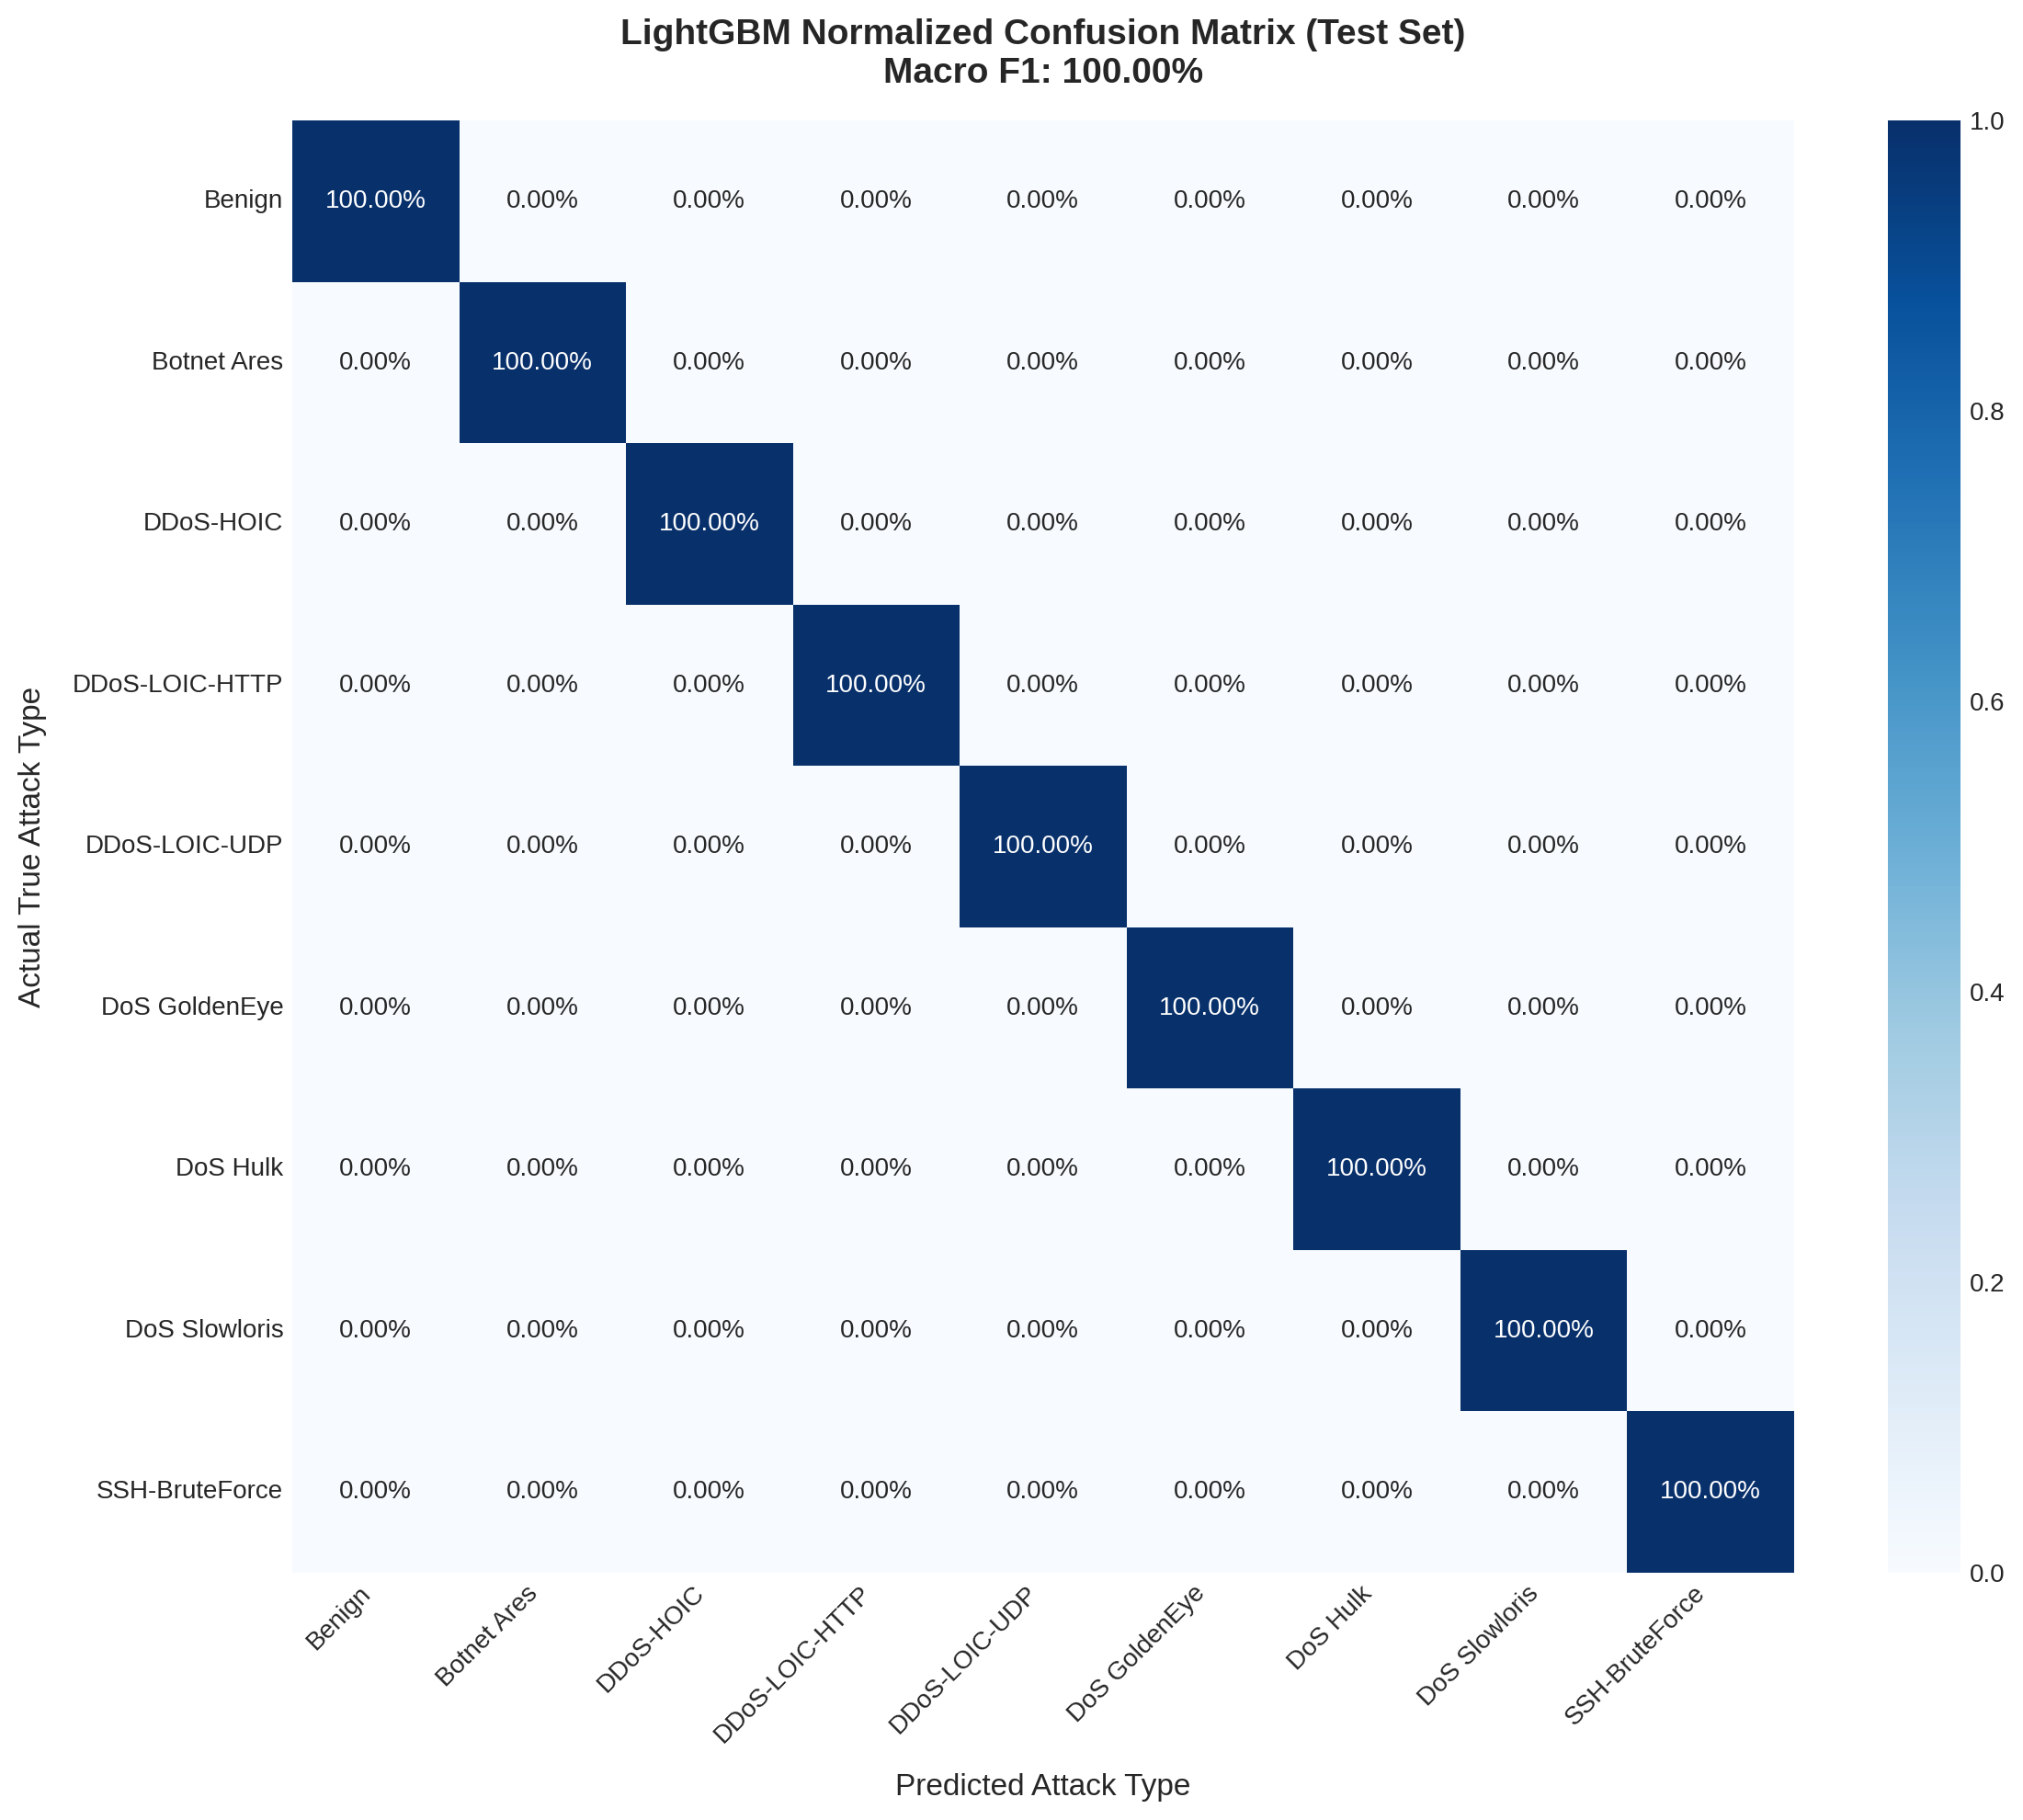

[+] Confusion matrix figure saved to:
    -> /content/drive/MyDrive/NIDS_Project/output/LightGBM_Confusion_Matrix.png


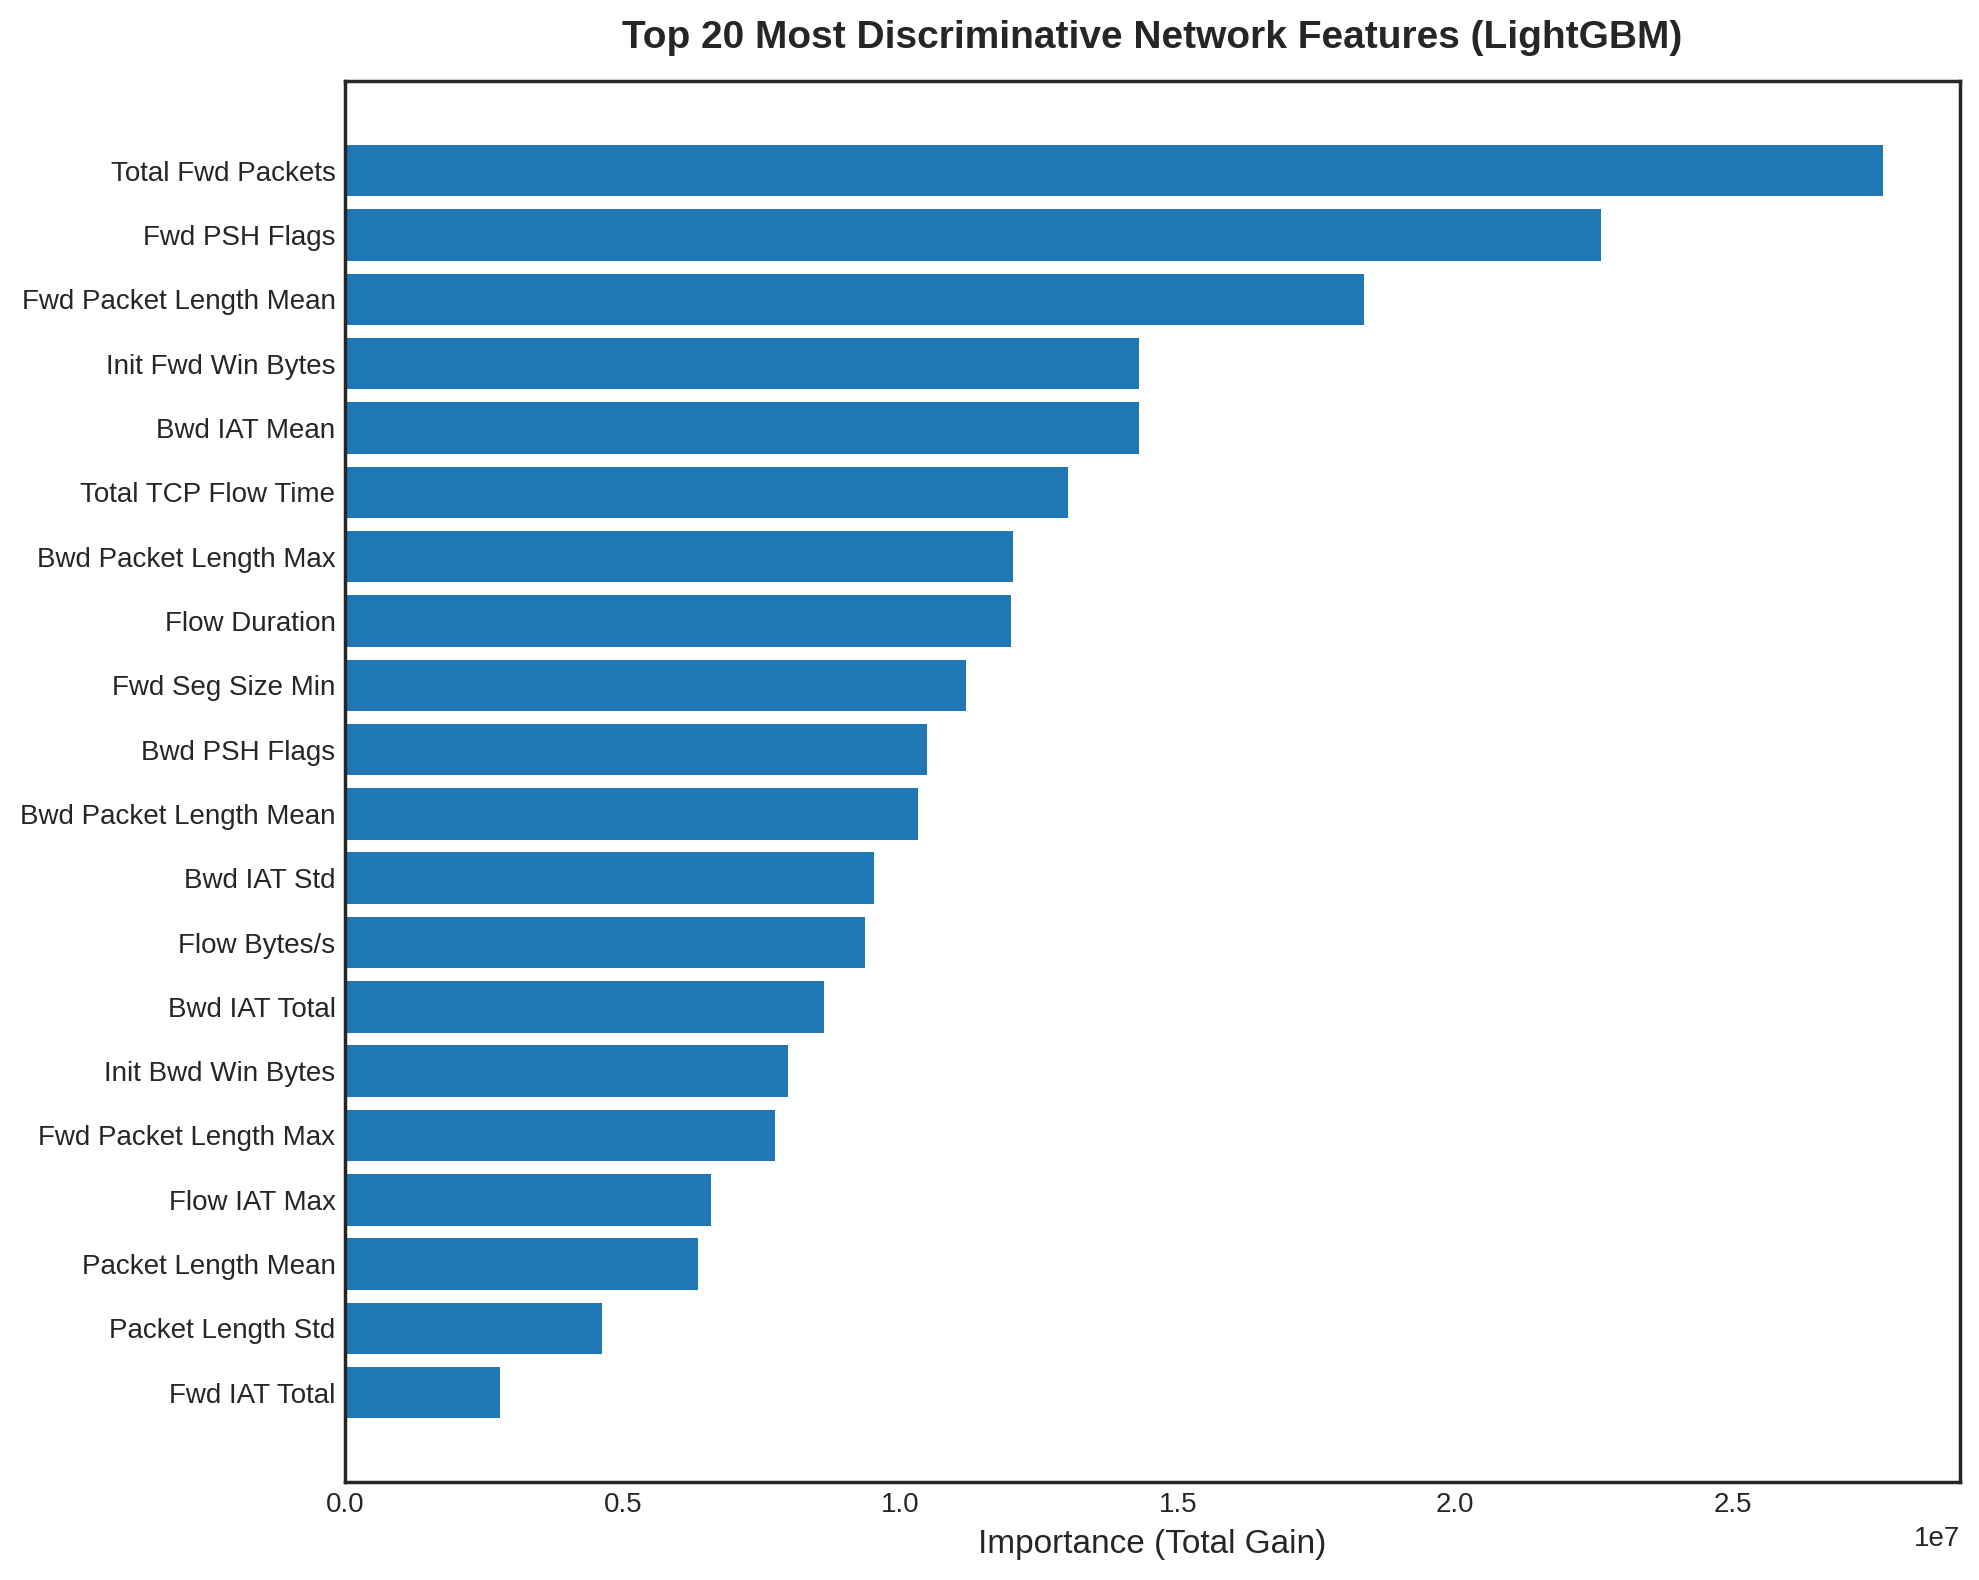

[+] Feature importance chart saved to:
    -> /content/drive/MyDrive/NIDS_Project/output/LightGBM_Feature_Importance.png


In [12]:
# ==============================================================
# Step 12: Plot and save the normalized confusion matrix and feature importance
# ==============================================================
plt.style.use("seaborn-v0_8-white")

# 1. Plot the normalized confusion matrix (per-class detection accuracy)
cm = confusion_matrix(y_test, y_pred, normalize="true")

plt.figure(figsize=(12, 10), dpi=200)
sns.heatmap(
    cm,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    cbar=True
)
plt.title(f"LightGBM Normalized Confusion Matrix (Test Set)\nMacro F1: {macro_f1:.2%}", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Predicted Attack Type", fontsize=12, labelpad=10)
plt.ylabel("Actual True Attack Type", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, "LightGBM_Confusion_Matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print(f"[+] Confusion matrix figure saved to:\n    -> {cm_path}")

# 2. Plot the top 20 most discriminative features (importance by gain)
importance = model.feature_importance(importance_type="gain")
sorted_idx = np.argsort(importance)[-20:]

plt.figure(figsize=(10, 8), dpi=200)
plt.barh(range(len(sorted_idx)), importance[sorted_idx], color="#1f77b4", align="center")
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx], fontsize=10)
plt.xlabel("Importance (Total Gain)", fontsize=12)
plt.title("Top 20 Most Discriminative Network Features (LightGBM)", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()

fi_path = os.path.join(SAVE_DIR, "LightGBM_Feature_Importance.png")
plt.savefig(fi_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()
print(f"[+] Feature importance chart saved to:\n    -> {fi_path}")


In [13]:
# ==============================================================
# Step 13: Save the trained model and metadata to Google Drive
# ==============================================================
# Save in LightGBM's native format (fastest to load, no extra dependencies)
model_txt_path = os.path.join(SAVE_DIR, "lightgbm_nids_model.txt")
model.save_model(model_txt_path)

# Save the Python model object with joblib
model_pkl_path = os.path.join(SAVE_DIR, "lightgbm_nids_model.pkl")
joblib.dump(model, model_pkl_path)

# Save the label mapping for inference
mapping_path = os.path.join(SAVE_DIR, "label_mapping.json")
with open(mapping_path, "w") as f:
    json.dump({"label_to_id": label_to_id, "id_to_label": id_to_label}, f, indent=4)

print(f"\n[+] Model saved in .txt format at: {model_txt_path}")
print(f"[+] Model saved in .pkl format at: {model_pkl_path}")
print(f"[+] Label mapping saved at: {mapping_path}")

# Final memory cleanup
del X_test, y_test, y_pred_probs, y_pred
gc.collect()



[+] Model saved in .txt format at: /content/drive/MyDrive/NIDS_Project/output/lightgbm_nids_model.txt
[+] Model saved in .pkl format at: /content/drive/MyDrive/NIDS_Project/output/lightgbm_nids_model.pkl
[+] Label mapping saved at: /content/drive/MyDrive/NIDS_Project/output/label_mapping.json


14815